C:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows wi

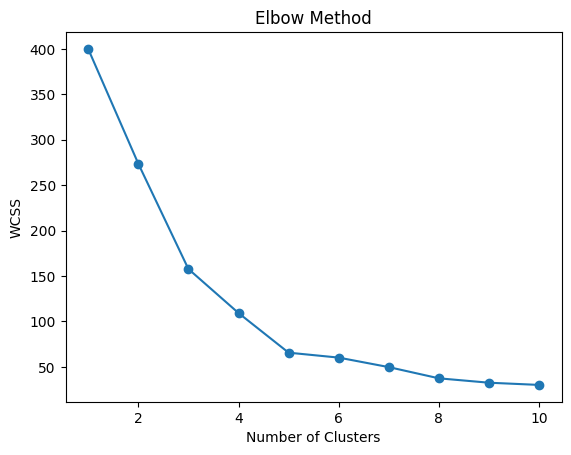

C:\Users\dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Silhouette Score: 0.5546571631111091


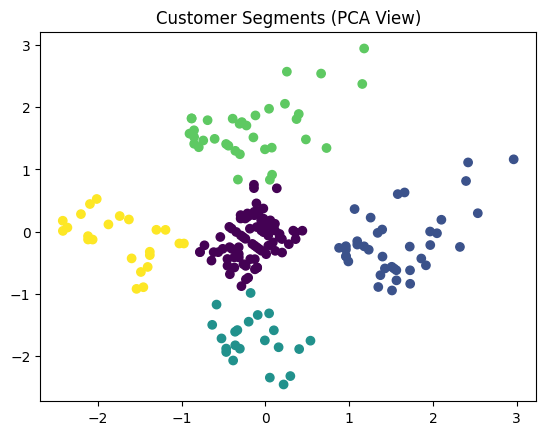

Cluster Centers (Income, Spending):
[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


In [1]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Step 2: Load Dataset
# Download from Kaggle: Mall Customer Segmentation Dataset
df = pd.read_csv("Mall_Customers.csv")

# Step 3: Select Important Features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Step 4: Scale Data (Very Important)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Elbow Method to Find Optimal K
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# Step 6: Apply KMeans (Assume K=5 from elbow)
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

# Step 7: Silhouette Score
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

# Step 8: PCA for 2D Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title("Customer Segments (PCA View)")
plt.show()

# Step 9: View Cluster Centers
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
print("Cluster Centers (Income, Spending):")
print(centroids)


Cluster labels: [ 0  0  0  0  1  1  1  1 -1]


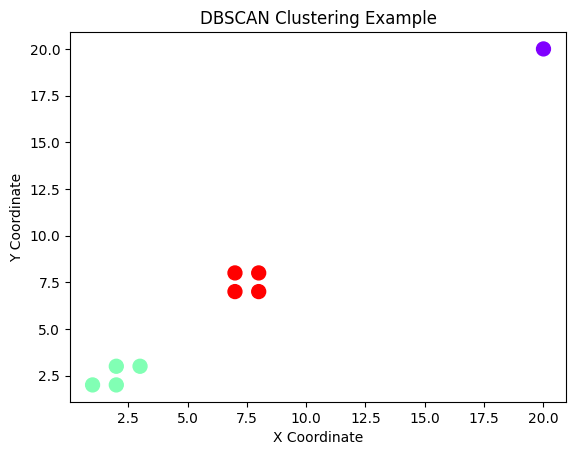

In [2]:
# Step 1: Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# Step 2: Create simple location dataset (X, Y coordinates)
X = np.array([
    [1,2], [2,2], [2,3], [3,3],      # Cluster 1
    [8,7], [8,8], [7,8], [7,7],      # Cluster 2
    [20,20]                          # Noise point
])

# Step 3: Apply DBSCAN
db = DBSCAN(eps=1.5, min_samples=2)
clusters = db.fit_predict(X)

# Step 4: Print cluster labels
print("Cluster labels:", clusters)

# Step 5: Visualize result
plt.scatter(X[:,0], X[:,1], c=clusters, cmap='rainbow', s=100)
plt.title("DBSCAN Clustering Example")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.show()


Cluster Labels: [ 0  0  0  0  0 -1]


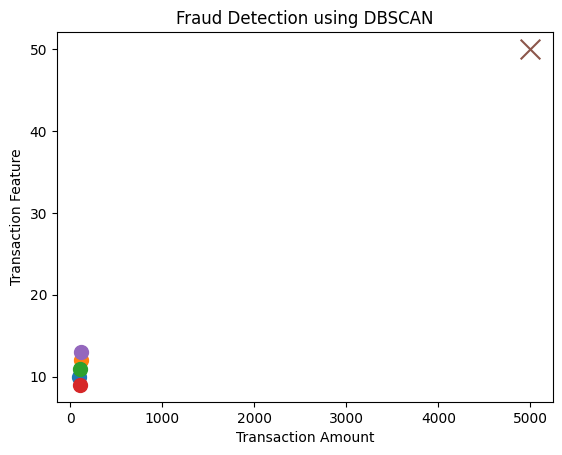

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# Dataset
data = np.array([
    [100,10],
    [120,12],
    [110,11],
    [105,9],
    [115,13],
    [5000,50]   # fraudulent transaction
])

# Apply DBSCAN
db = DBSCAN(eps=20, min_samples=2)
labels = db.fit_predict(data)

print("Cluster Labels:", labels)

# Plotting
for i in range(len(data)):
    if labels[i] == -1:
        plt.scatter(data[i][0], data[i][1], marker='x', s=200, label="Noise")
    else:
        plt.scatter(data[i][0], data[i][1], marker='o', s=100, label="Cluster")

plt.xlabel("Transaction Amount")
plt.ylabel("Transaction Feature")
plt.title("Fraud Detection using DBSCAN")
plt.show()



Cluster Labels: [ 0  0  0  1  1  1 -1]


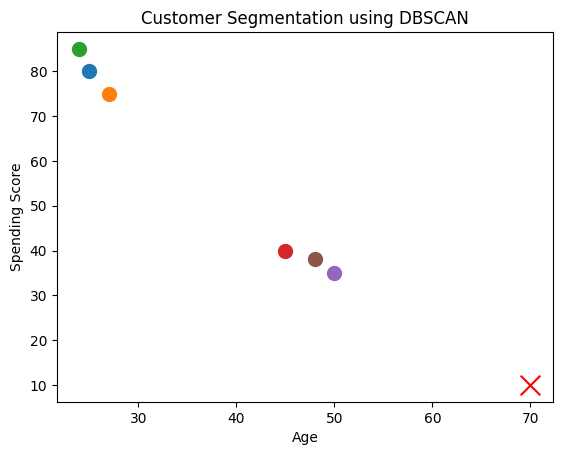

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# Dataset
data = np.array([
    [25,80],
    [27,75],
    [24,85],
    [45,40],
    [50,35],
    [48,38],
    [70,10]   # outlier
])

# Apply DBSCAN
db = DBSCAN(eps=10, min_samples=2)
labels = db.fit_predict(data)

print("Cluster Labels:", labels)

# Plot
for i in range(len(data)):
    if labels[i] == -1:
        plt.scatter(data[i][0], data[i][1], color='red', marker='x', s=200)
    else:
        plt.scatter(data[i][0], data[i][1], s=100)

plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using DBSCAN")
plt.show()
  